In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df=pd.read_csv('diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
cols = ['Glucose', 'BloodPressure', 'BMI']

for col in cols:
    print(col, (df[col] == 0).sum())

Glucose 5
BloodPressure 35
BMI 11


In [ ]:
(df == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [ ]:
invalid_zero_cols = ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness', 'Insulin']

In [ ]:
X[invalid_zero_cols] = X[invalid_zero_cols].replace(0, np.nan)

In [ ]:
preprocessor = ColumnTransformer([
    ('imputer', SimpleImputer(strategy='median'), invalid_zero_cols)
], remainder='passthrough')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)
}

In [ ]:
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    # Cross-validation
    cv_score = cross_val_score(pipe, X, y, cv=5, scoring='f1')
    print("CV F1 Score:", cv_score.mean())


Logistic Regression
[[82 18]
 [27 27]]
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

CV F1 Score: 0.6334241698073979

KNN
[[83 17]
 [21 33]]
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154

CV F1 Score: 0.6128576230043559

SVM
[[84 16]
 [24 30]]
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                  

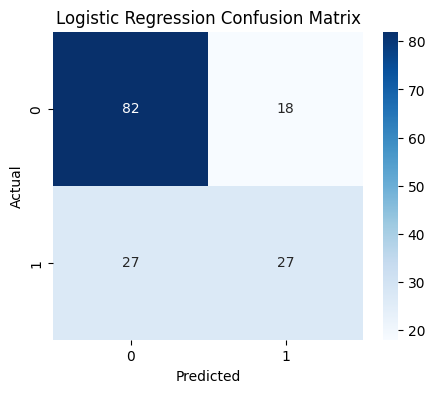

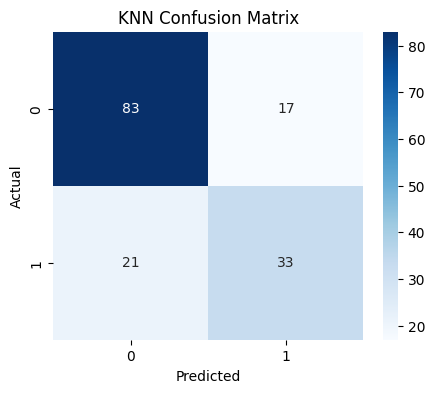

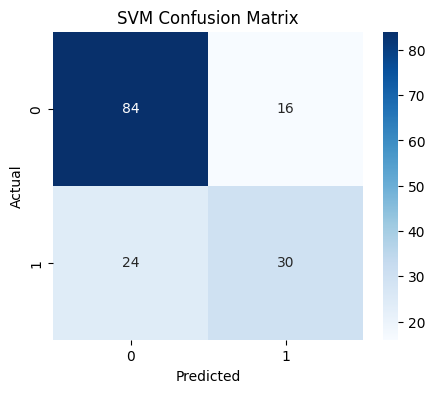

In [ ]:
# Define models
models = { "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)}

for name, model in models.items():

    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict
    y_pred = pipe.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[0,1], yticklabels=[0,1])

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [ ]:
advanced_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_split=5,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3
    ),

    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss'
    )
}

In [ ]:
for name, model in advanced_models.items():
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    # Cross-validation
    cv_score = cross_val_score(pipe, X, y, cv=5, scoring='f1')
    print("CV F1 Score:", cv_score.mean())


Random Forest
[[86 14]
 [27 27]]
              precision    recall  f1-score   support

           0       0.76      0.86      0.81       100
           1       0.66      0.50      0.57        54

    accuracy                           0.73       154
   macro avg       0.71      0.68      0.69       154
weighted avg       0.73      0.73      0.72       154

CV F1 Score: 0.6071082965685002

Gradient Boosting
[[85 15]
 [21 33]]
              precision    recall  f1-score   support

           0       0.80      0.85      0.83       100
           1       0.69      0.61      0.65        54

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154

CV F1 Score: 0.6459532515565802

XGBoost
[[82 18]
 [20 34]]
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       100
           1       0.65      0.63      0.64        54

    accuracy      

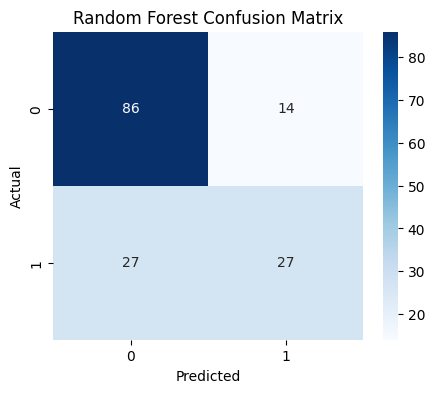

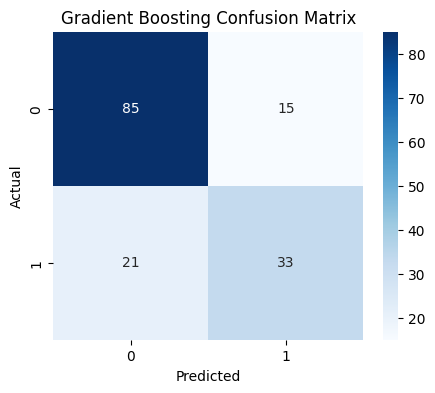

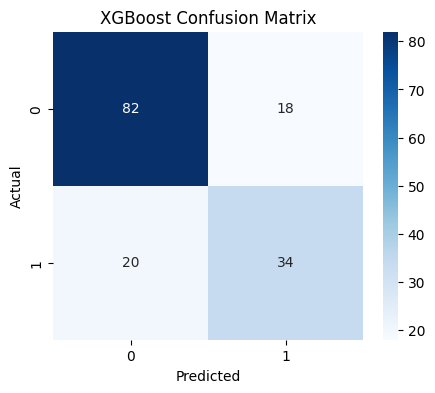

In [ ]:
for name, model in advanced_models.items():

    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('scaler', StandardScaler()),  # safe to keep
        ('model', model)
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict
    y_pred = pipe.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[0,1], yticklabels=[0,1])

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [ ]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=3,   #Limits tree complexity
    learning_rate=0.05,
    subsample=0.8,   #Uses random data → prevents overfitting
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('scaler', StandardScaler()),
    ('model', model)
])

pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer',
                                                  SimpleImputer(strategy='median'),
                                                  ['Glucose', 'BloodPressure',
                                                   'BMI', 'SkinThickness',
                                                   'Insulin'])])),
                ('scaler', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_byt...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'model__n_estimators': [200, 300, 400],
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 1]
}

random_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,      #prevents overfitting
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)   #Trains XGBoost, Tries different parameter combinations, Finds best model

best_model = random_search.best_estimator_

print("Best Params:", random_search.best_params_)

Best Params: {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.03}


In [ ]:
y_prob = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_prob > t).astype(int)

    results.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    })

df_thresh = pd.DataFrame(results)
print(df_thresh)

    threshold  precision    recall        f1
0        0.10   0.490566  0.962963  0.650000
1        0.15   0.525773  0.944444  0.675497
2        0.20   0.544444  0.907407  0.680556
3        0.25   0.558140  0.888889  0.685714
4        0.30   0.573171  0.870370  0.691176
5        0.35   0.589744  0.851852  0.696970
6        0.40   0.592105  0.833333  0.692308
7        0.45   0.602740  0.814815  0.692913
8        0.50   0.614286  0.796296  0.693548
9        0.55   0.627119  0.685185  0.654867
10       0.60   0.622642  0.611111  0.616822
11       0.65   0.666667  0.555556  0.606061
12       0.70   0.707317  0.537037  0.610526
13       0.75   0.714286  0.462963  0.561798
14       0.80   0.714286  0.370370  0.487805
15       0.85   0.681818  0.277778  0.394737


In [ ]:
best_threshold = 0.3   # (example — choose from your table)

In [ ]:
y_final = (y_prob > best_threshold).astype(int)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_final))
print(classification_report(y_test, y_final))

[[65 35]
 [ 7 47]]
              precision    recall  f1-score   support

           0       0.90      0.65      0.76       100
           1       0.57      0.87      0.69        54

    accuracy                           0.73       154
   macro avg       0.74      0.76      0.72       154
weighted avg       0.79      0.73      0.73       154



 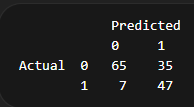



0,0-TN  (model correctly predicts 65 no diabetes)

0,1-FP  (model predicts diabetes but actual no diabetes)

1,0-FN  (model predicts no diabetes but actual diabetes)

1,1-TP  (model corectly predicts diabetes)

actual diabetes=7+47=54

Recall = TP / (TP + FN) [how many actual diabetics you caught]


       = 47 / (47 + 7)

       = 47 / 54 = 0.87

predicted diabetes=35+47=82

Precision = TP / (TP + FP)[how many predicted diabetics were correct]

          = 47 / (47 + 35)

          = 47 / 82 = 0.57

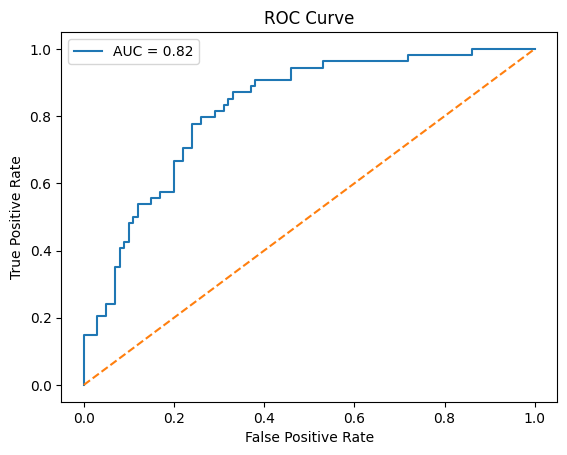

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

Overfitting checking

In [ ]:
print("Train score:", best_model.score(X_train, y_train))
print("Test score:", best_model.score(X_test, y_test))

Train score: 0.8420195439739414
Test score: 0.7532467532467533


In [ ]:
y_prob_full = best_model.predict_proba(X)[:, 1]
y_pred_full = (y_prob_full > best_threshold).astype(int)

In [ ]:
df['Predicted_Probability'] = y_prob_full
df['Predicted_Label'] = y_pred_full

In [ ]:
df.to_csv("diabetes_predictions.csv", index=False)